# Buổi 8 — Notebook 1: Khám phá dữ liệu (EDA)

**Mục đích của notebook này:**  
Hiểu dữ liệu trước khi xây dựng mô hình. Mọi quyết định về tiền xử lý và lựa chọn mô hình đều bắt đầu từ đây.

**Việc của bạn:** Hoàn thiện các hàm trong `src/eda.py`, rồi chạy lần lượt từng ô bên dưới.

---
> Nếu một ô báo lỗi `NotImplementedError`, bạn chưa hoàn thiện hàm tương ứng trong `src/eda.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from src import eda

## 1. Tải dữ liệu

In [2]:
df, wine = eda.tai_du_lieu()

print(f'Kích thước : {df.shape}')
print(f'Nhóm rượu : {list(wine.target_names)}')
print(f'Đặc trưng : {list(wine.feature_names)}')
df.head()

Kích thước : (178, 15)
Nhóm rượu : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Đặc trưng : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,nhan,loai_ruou
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Kiểm tra giá trị thiếu

**Hàm cần hoàn thiện:** `eda.kiem_tra_gia_tri_thieu()`

In [3]:
so_nan = eda.kiem_tra_gia_tri_thieu(df)

Không có giá trị thiếu. Dữ liệu đầy đủ.


## 3. Thống kê mô tả

Hãy chú ý đến phạm vi giá trị của từng đặc trưng.

In [4]:
feature_cols = list(wine.feature_names)
eda.thong_ke_mo_ta(df, feature_cols)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.0006,0.8118,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.3363,1.1171,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.3665,0.2743,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.4949,3.3396,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.7416,14.2825,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.2951,0.6259,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.0293,0.9989,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.3619,0.1245,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.5909,0.5724,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.0581,2.3183,1.28,3.2200,4.690,6.2000,13.00


> **Câu hỏi 1:** Đặc trưng nào có giá trị lớn nhất? Nhỏ nhất?  
> **Câu hỏi 2:** Sự chênh lệch tỉ lệ này có ảnh hưởng đến KNN không? Tại sao?

**Đáp án 1:**  
- **Lớn nhất:** `proline` — mean ≈ 747, max = 1 680.  
- **Nhỏ nhất:** `nonflavanoid_phenols` — mean ≈ 0.36, max = 0.66.  
- Khoảng chênh lệch: `proline` lớn hơn `nonflavanoid_phenols` khoảng **2 000 lần**.

**Đáp án 2:**  
**Có ảnh hưởng rất lớn.** KNN tính khoảng cách Euclidean giữa các điểm dữ liệu. Khi `proline` có giá trị ~700 còn `nonflavanoid_phenols` chỉ ~0.3, khoảng cách sẽ bị chi phối hoàn toàn bởi `proline` — các đặc trưng nhỏ gần như không đóng góp gì. Điều này khiến mô hình bỏ qua thông tin quan trọng từ các đặc trưng tỉ lệ nhỏ. **Giải pháp: chuẩn hóa (StandardScaler) trước khi dùng KNN.**

## 4. Phân phối nhãn

**Hàm cần hoàn thiện:** `eda.ve_phan_phoi_nhan()`

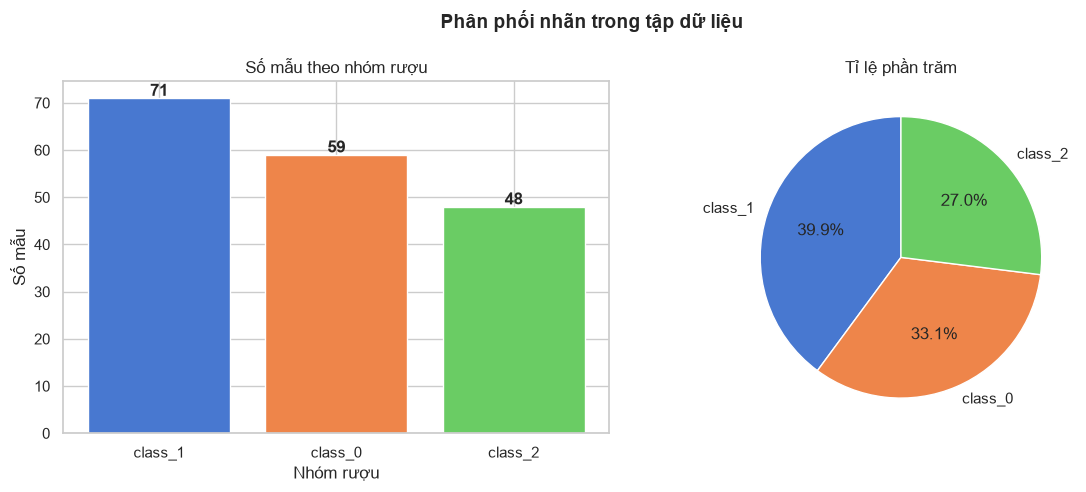

In [5]:
fig = eda.ve_phan_phoi_nhan(df)
plt.show()

> **Câu hỏi 3:** Dữ liệu có cân bằng không? Điều đó ảnh hưởng gì đến quá trình huấn luyện?

**Đáp án 3:**  
Dữ liệu **tương đối cân bằng** nhưng không hoàn toàn đều:  
- class_0: 59 mẫu (33.1%)  
- class_1: 71 mẫu (39.9%)  
- class_2: 48 mẫu (27.0%)  

Chênh lệch nhỏ (< 15%) nên **không gây vấn đề nghiêm trọng**. Tuy nhiên nếu mất cân bằng lớn, mô hình có xu hướng nghiêng về lớp đa số và bỏ qua lớp thiểu số. Đó là lý do ta dùng `stratify=y` khi chia tập dữ liệu — để giữ nguyên tỉ lệ này trong cả train và test.

## 5. Phân phối đặc trưng theo nhóm

**Hàm cần hoàn thiện:** `eda.ve_histogram_dac_trung()`

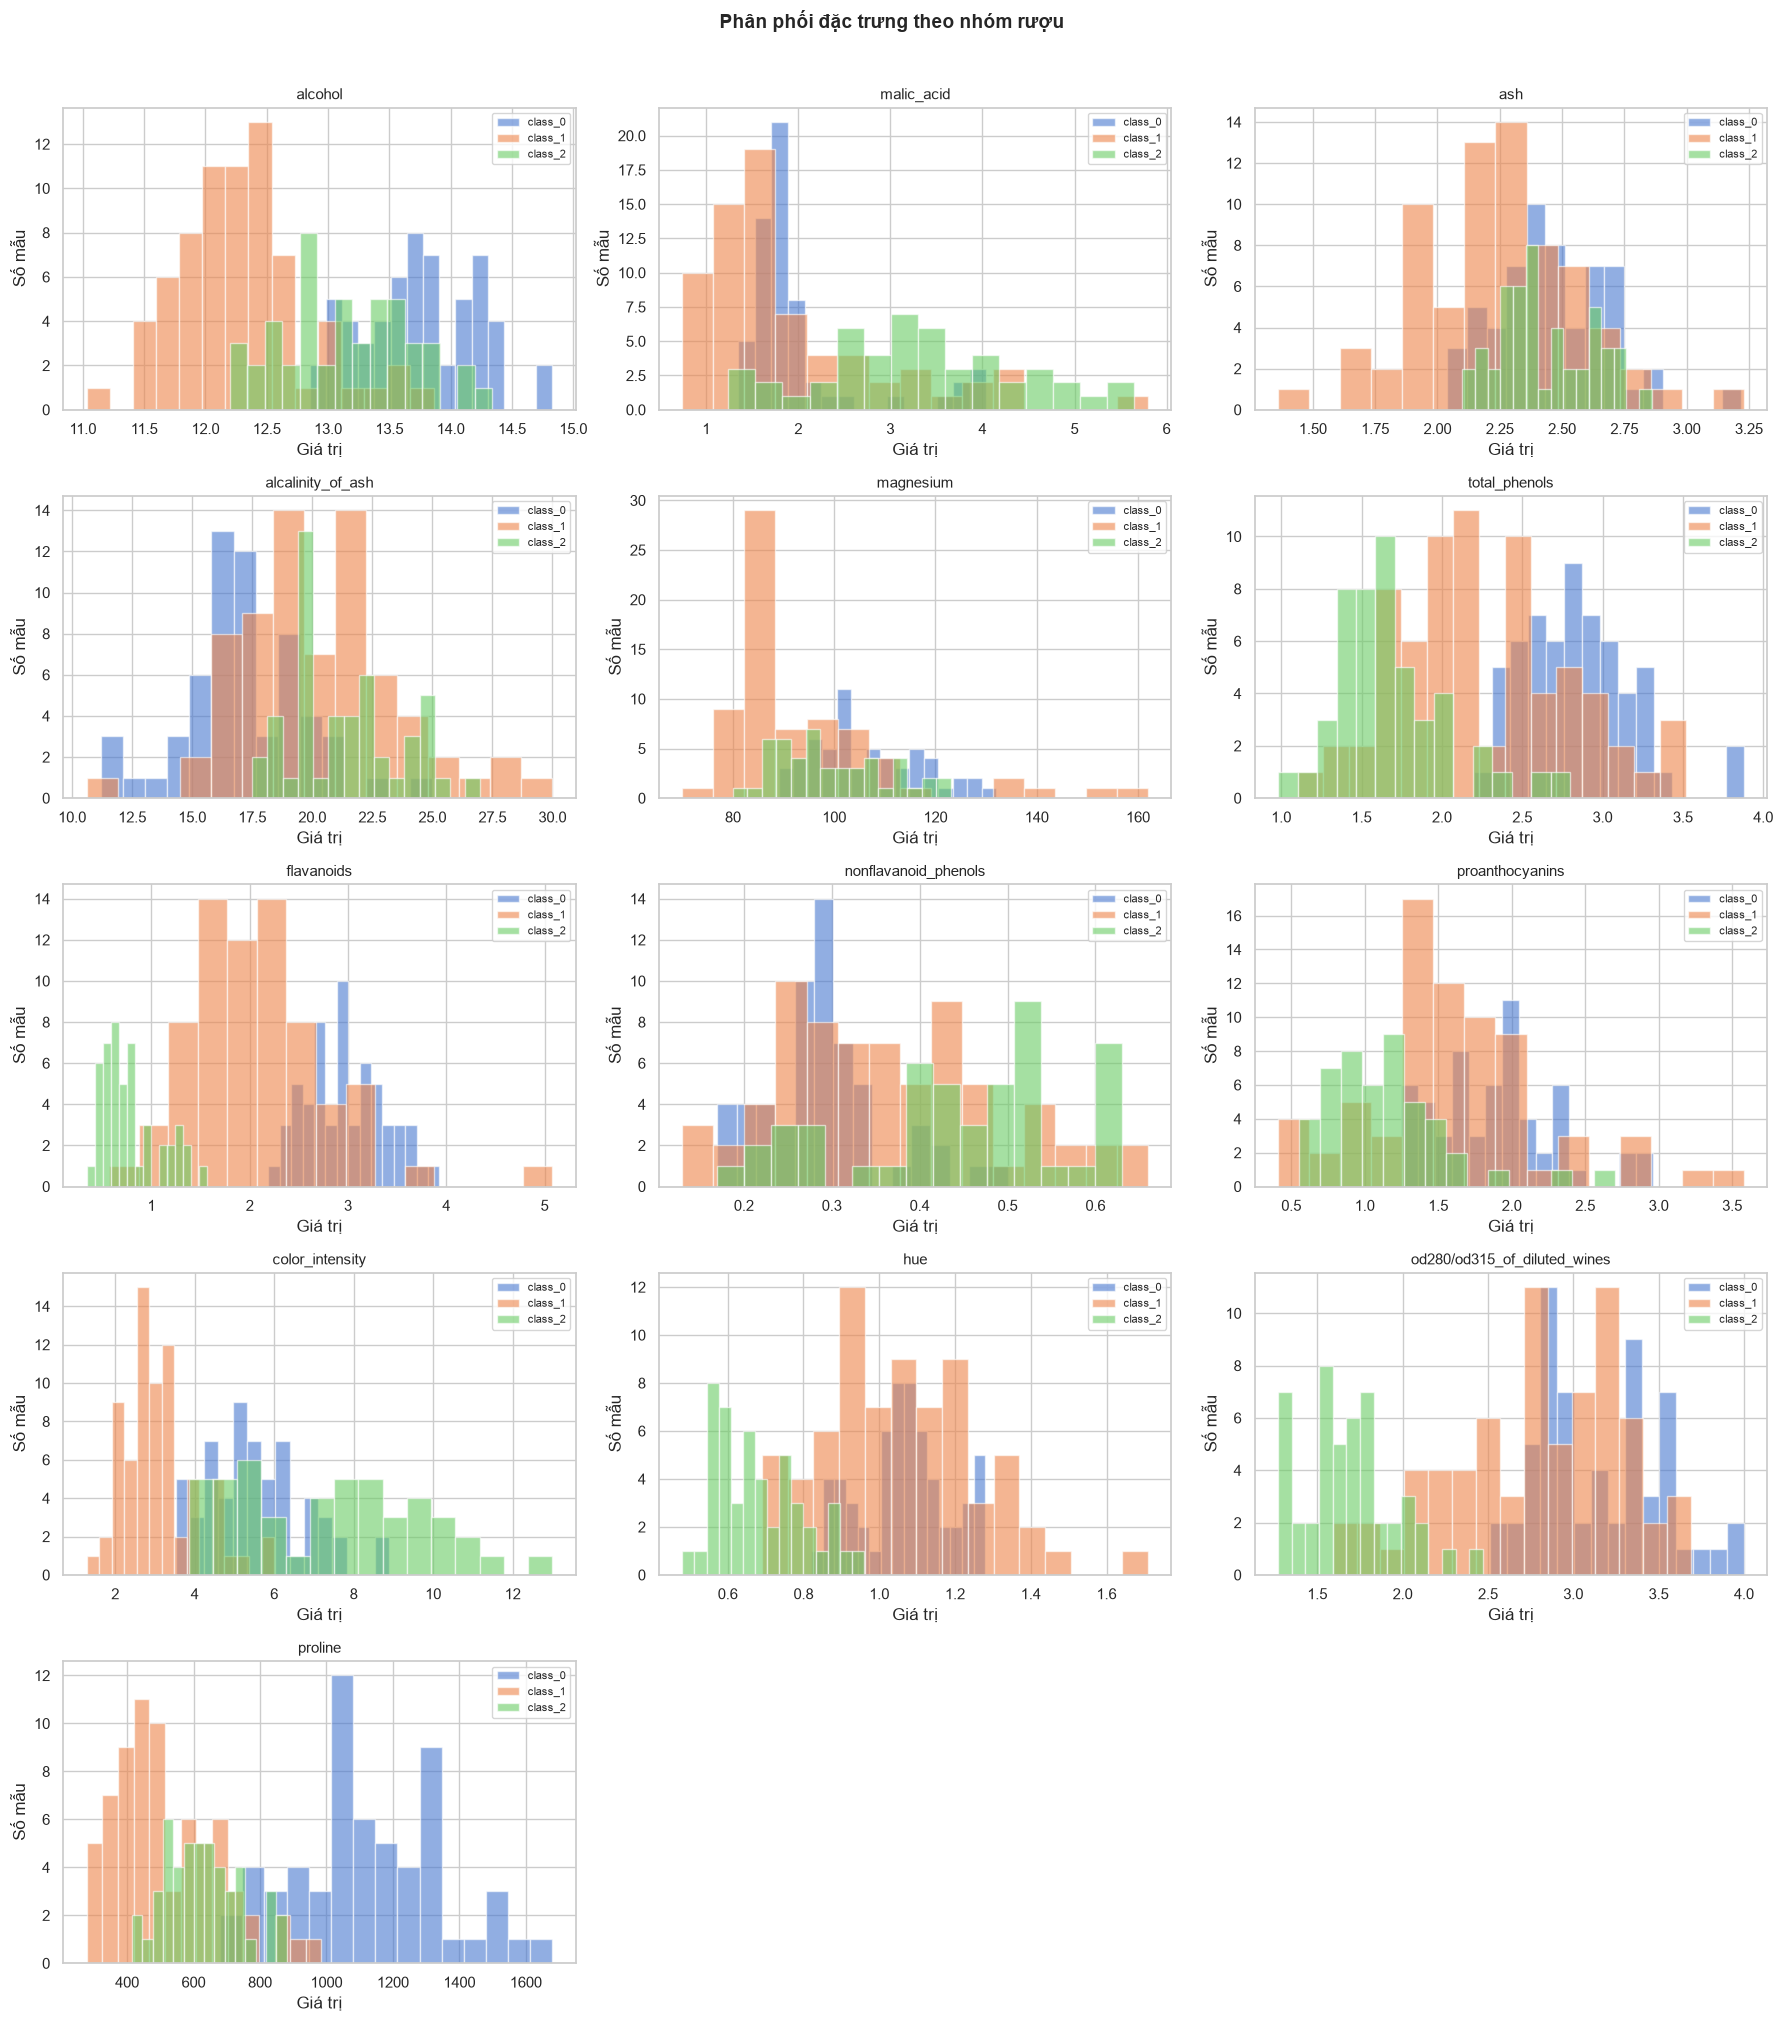

In [6]:
fig = eda.ve_histogram_dac_trung(df, feature_cols)
plt.show()

> **Câu hỏi 4:** Nhìn vào các histogram, đặc trưng nào giúp phân biệt 3 nhóm rõ nhất?

**Đáp án 4:**  
Các đặc trưng có histogram **ít chồng lên nhau** giữa 3 nhóm là dấu hiệu phân biệt tốt:  
- **`flavanoids`**: class_0 tập trung cao (~2.5–4), class_2 thấp (~0.3–1.5) — phân tách rõ.  
- **`proline`**: class_0 rất cao (~900–1500), class_2 thấp (~300–600) — dễ tách.  
- **`od280/od315_of_diluted_wines`**: 3 nhóm có dải giá trị khác nhau rõ rệt.  
- **`color_intensity`**: class_0 và class_2 phân tách tốt với class_1.  

Ngược lại, `ash` và `alcalinity_of_ash` có histogram chồng lên nhau nhiều → khó phân biệt.

## 6. Biểu đồ hộp (boxplot)

C:\Users\ngocb\AppData\Local\Temp\ipykernel_36920\1068348921.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loai_ruou', y=feat, palette='muted', ax=axes[i])
C:\Users\ngocb\AppData\Local\Temp\ipykernel_36920\1068348921.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loai_ruou', y=feat, palette='muted', ax=axes[i])
C:\Users\ngocb\AppData\Local\Temp\ipykernel_36920\1068348921.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loai_ruou', y=feat, palette='muted', ax=axes[i])
C:\Users\ngocb\AppData

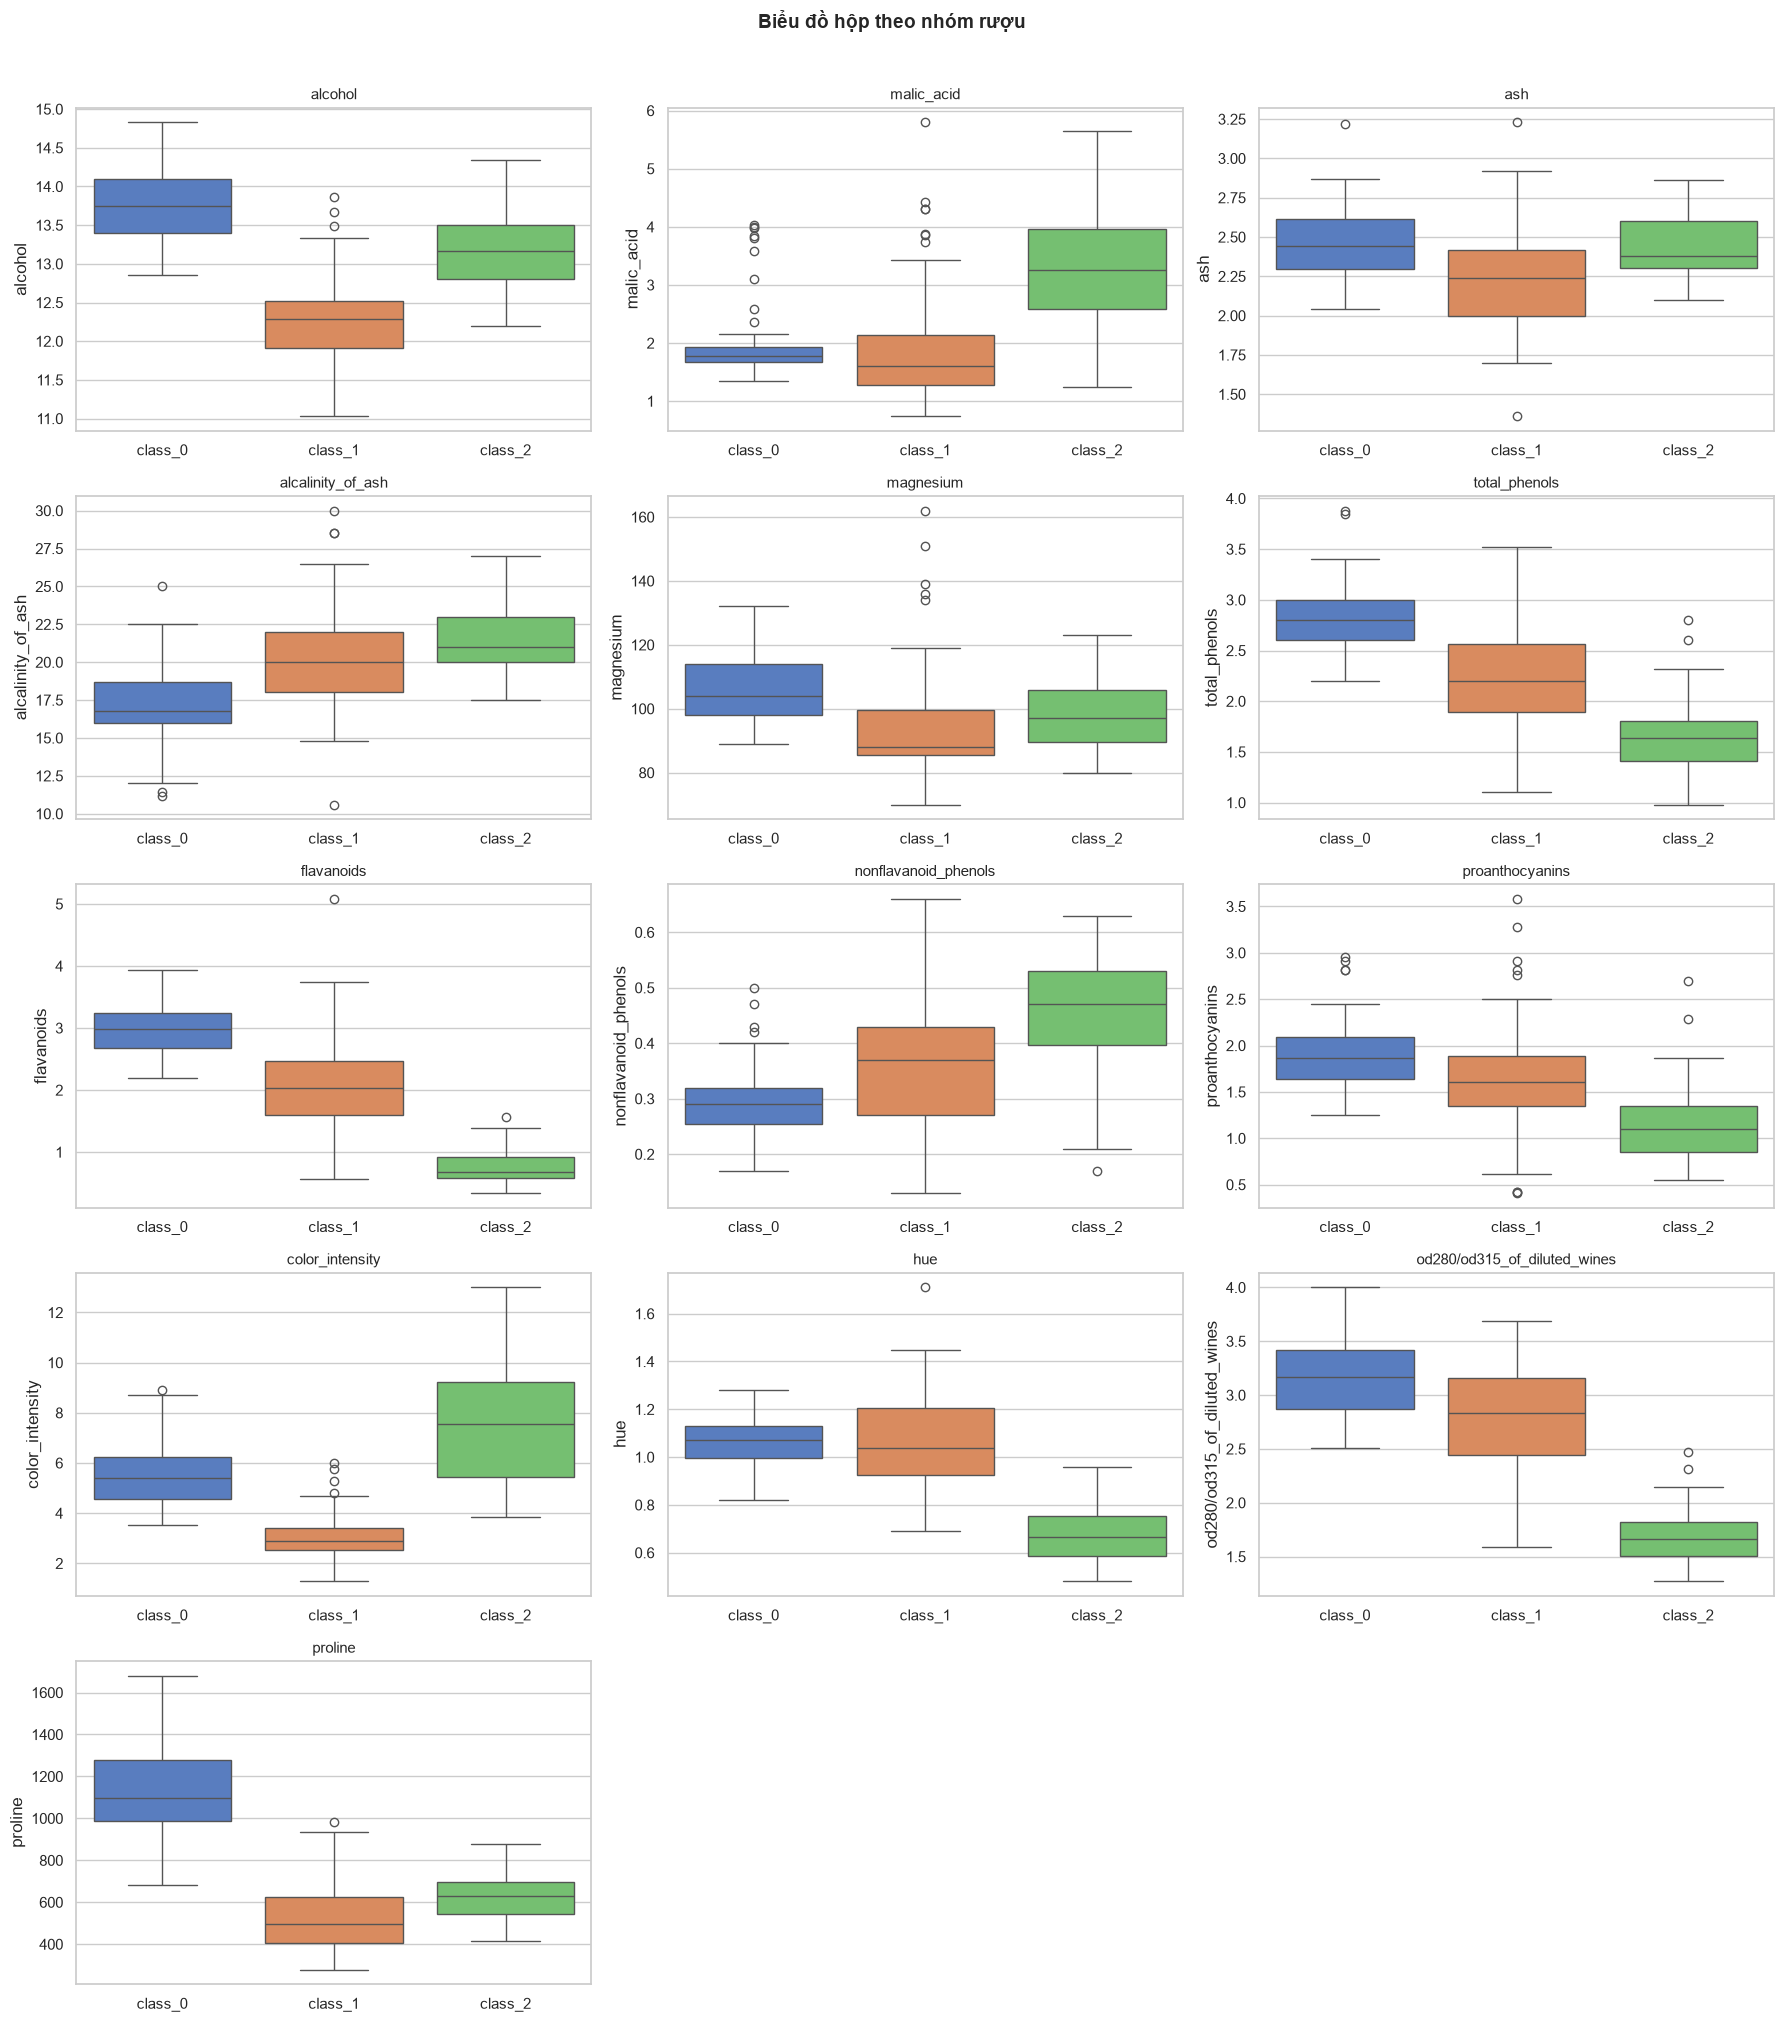

In [7]:
# Hàm này đã được cung cấp sẵn — chỉ cần chạy
import seaborn as sns
import numpy as np

n_cols = 3
n_rows = -(-len(feature_cols) // n_cols)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    sns.boxplot(data=df, x='loai_ruou', y=feat, palette='muted', ax=axes[i])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
for k in range(len(feature_cols), len(axes)):
    axes[k].set_visible(False)
plt.suptitle('Biểu đồ hộp theo nhóm rượu', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Ma trận tương quan

**Hàm cần hoàn thiện:** `eda.ve_heatmap_tuong_quan()`

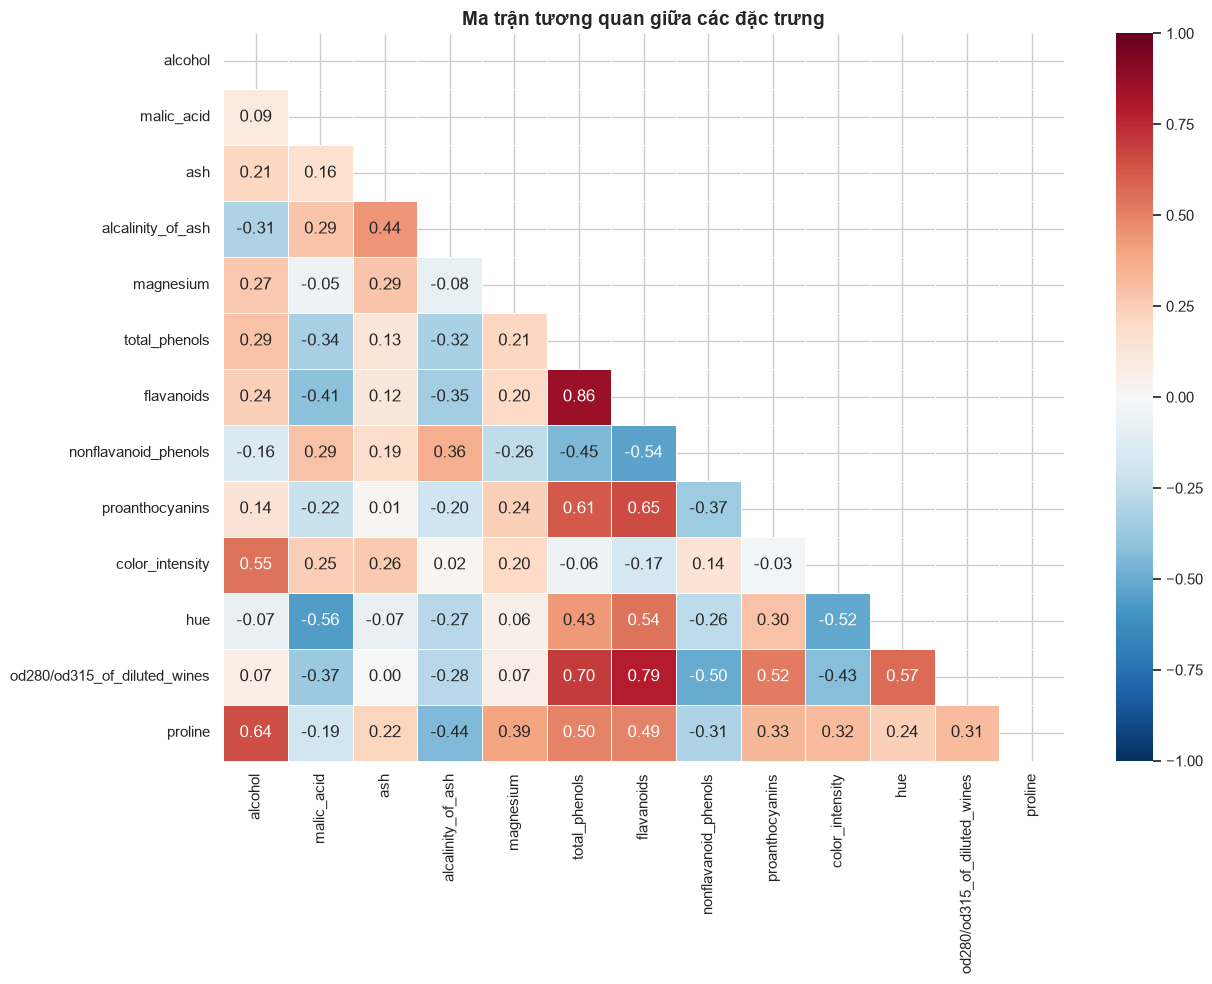

In [8]:
fig = eda.ve_heatmap_tuong_quan(df, feature_cols)
plt.show()

> **Câu hỏi 5:** Tìm 2 cặp đặc trưng có tương quan cao nhất. Tương quan cao ảnh hưởng gì đến KNN?

**Đáp án 5:**  
Hai cặp tương quan cao nhất (tương quan dương mạnh):  
1. **`flavanoids` ↔ `total_phenols`**: r ≈ +0.86  
2. **`flavanoids` ↔ `od280/od315_of_diluted_wines`**: r ≈ +0.79  

**Ảnh hưởng đến KNN:** Khi hai đặc trưng tương quan cao, chúng mang gần như cùng một thông tin. Trong khoảng cách Euclidean, thông tin đó bị **đếm hai lần** → mô hình KNN bị lệch về chiều đó, làm giảm độ chính xác. Giải pháp: loại bỏ đặc trưng trùng lặp hoặc dùng PCA để giảm chiều.

## 8. Top 5 đặc trưng phân biệt nhóm

**Hàm cần hoàn thiện:** `eda.top_dac_trung_phan_biet()`

In [9]:
top5 = eda.top_dac_trung_phan_biet(df, feature_cols, n=5)
print('Top 5 đặc trưng phân biệt nhóm tốt nhất:')
for ten, val in top5.items():
    print(f'  {ten}: {val:.3f}')

Top 5 đặc trưng phân biệt nhóm tốt nhất:
  flavanoids: 0.847
  od280/od315_of_diluted_wines: 0.788
  total_phenols: 0.719
  proline: 0.634
  hue: 0.617


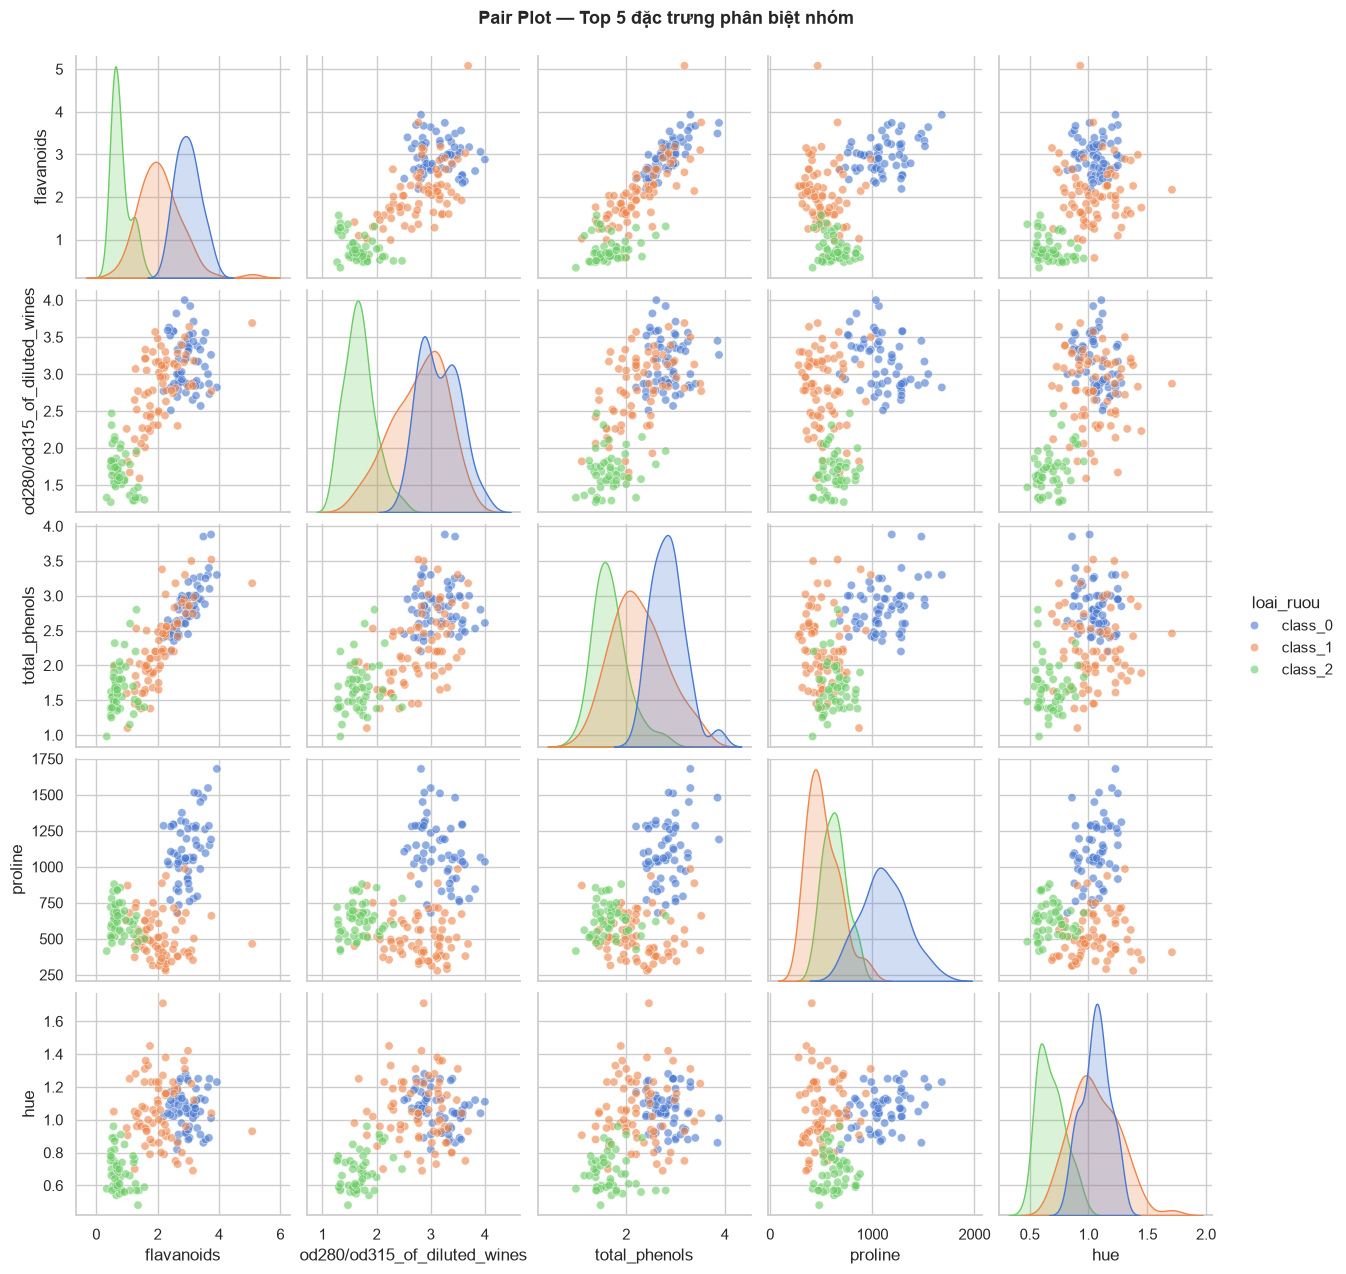

In [10]:
# Pair plot — hàm đã cung cấp sẵn
import seaborn as sns
g = sns.pairplot(
    df[list(top5.index) + ['loai_ruou']],
    hue='loai_ruou', palette='muted',
    diag_kind='kde', plot_kws={'alpha': 0.6}
)
g.fig.suptitle('Pair Plot — Top 5 đặc trưng phân biệt nhóm', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 9. Ảnh hưởng của chuẩn hóa

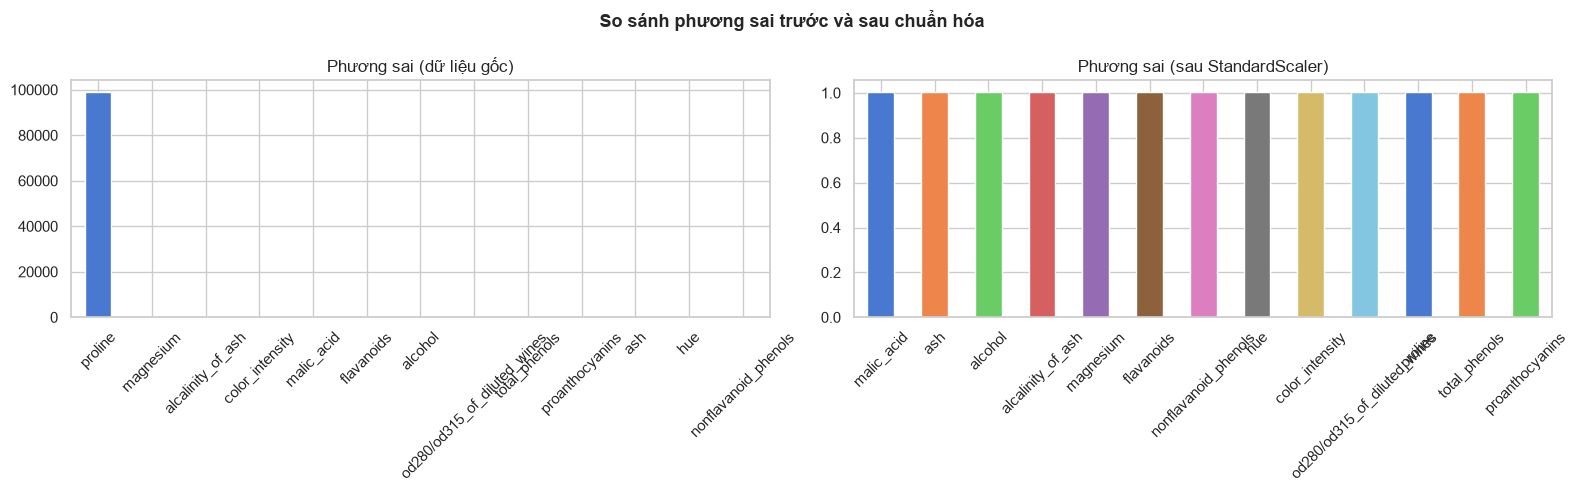

In [11]:
# Hàm đã cung cấp sẵn — minh họa tại sao KNN cần chuẩn hóa
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_viz = StandardScaler()
X_norm = scaler_viz.fit_transform(df[feature_cols])
df_norm = pd.DataFrame(X_norm, columns=feature_cols)

pv_goc = df[feature_cols].var().sort_values(ascending=False)
pv_norm = df_norm.var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pv_goc.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(feature_cols)))
axes[0].set_title('Phương sai (dữ liệu gốc)')
axes[0].tick_params(axis='x', rotation=45)

pv_norm.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', len(feature_cols)))
axes[1].set_title('Phương sai (sau StandardScaler)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('So sánh phương sai trước và sau chuẩn hóa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Tổng kết EDA — Điền vào bảng

| Đặc điểm | Kết quả |
|---|---|
| Số mẫu | 178 |
| Số đặc trưng | 13 |
| Số nhóm | 3 (class_0, class_1, class_2) |
| Có giá trị thiếu? | Không |
| Dữ liệu cân bằng? | Tương đối — 59 / 71 / 48 mẫu (27–40%) |
| Có vấn đề tỉ lệ? | **Có** — `proline` (~747) lớn hơn `nonflavanoid_phenols` (~0.36) ~2 000 lần |
| Top đặc trưng phân biệt | flavanoids, od280/od315_of_diluted_wines, total_phenols, proline, hue |

**→ Kết luận:**  
- **KNN cần chuẩn hóa** — dùng khoảng cách Euclidean nên bị chi phối bởi đặc trưng có thang đo lớn. StandardScaler đưa tất cả về mean=0, std=1.  
- **Decision Tree không cần chuẩn hóa** — chia theo ngưỡng (threshold) nên không phụ thuộc vào tỉ lệ tuyệt đối của giá trị.

---
*Tiếp theo: `02_KNN.ipynb`*